In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## **Membaca Sheet #1**

### **STEP 1: Mengenali data pada Sheet 1 - Tentang Anomali**

In [ ]:
# Membaca sheet
df = pd.read_excel("data_latihan_bi_kotor.xlsx", sheet_name = "Transaksi_BI")

Exception ignored in: <function ZipFile.__del__ at 0x7ecc4fef2160>
Traceback (most recent call last):
  File "/usr/lib/python3.13/zipfile/__init__.py", line 2017, in __del__
    self.close()
  File "/usr/lib/python3.13/zipfile/__init__.py", line 2034, in close
    self.fp.seek(self.start_dir)
ValueError: seek of closed file


In [ ]:
print(df.head(10).to_string())

      Tanggal Kode_Transaksi           Kantor_BI Kanal_Pembayaran Jenis_Transaksi     Kategori Nilai_Transaksi  Biaya_Admin
0  2024-03-01      TRX000001   KPwBI DKI Jakarta             QRIS      Pemerintah   Penerimaan      -582831000       2500.0
1  2024-10-20      TRX000002          KPwBI Bali            Tunai        Individu  Pengeluaran     657.755.000          0.0
2  2024-01-02      TRX000003   KPwBI DKI Jakarta      Kartu Debit        Individu  Pengeluaran             NaN       2500.0
3  2024-12-16      TRX000004          KPwBI Bali            Tunai       Korporasi   Penerimaan      -283496000          0.0
4  01/07/2024      TRX000005  KPwBI DKI Jakarta      Kartu Kredit       Korporasi   Penerimaan       651078000       5000.0
5  2024-08-22      TRX000006   KPwBI Jawa Timur              QRIS       Korporasi  Pengeluaran       633874000       2500.0
6  29/12/2024      TRX000007   KPwBI DKI Jakarta            tunai        Individu   Penerimaan       415504000          0.0
7  29/02

Catat anomali yang tidak sesuai

In [ ]:
# Melihat tipe data pada setiap kolom
print(df.dtypes)

Tanggal              object
Kode_Transaksi       object
Kantor_BI            object
Kanal_Pembayaran     object
Jenis_Transaksi      object
Kategori             object
Nilai_Transaksi      object
Biaya_Admin         float64
dtype: object


In [ ]:
# Melihat nilai missing value pada setiap kolom
print(df.isnull().sum())

Tanggal             0
Kode_Transaksi      0
Kantor_BI           4
Kanal_Pembayaran    4
Jenis_Transaksi     3
Kategori            2
Nilai_Transaksi     5
Biaya_Admin         6
dtype: int64


In [ ]:
df.columns.to_list()

['Tanggal',
 'Kode_Transaksi',
 'Kantor_BI',
 'Kanal_Pembayaran',
 'Jenis_Transaksi',
 'Kategori',
 'Nilai_Transaksi',
 'Biaya_Admin']

In [ ]:
# Melihat unique value pada setiap kolom
for nama_kolom in ['Tanggal', 'Kode_Transaksi', 'Kantor_BI', 'Kanal_Pembayaran',
       'Jenis_Transaksi', 'Kategori', 'Nilai_Transaksi', 'Biaya_Admin']:
  print(nama_kolom, ":->", list(df[nama_kolom].unique()))
  print()

Tanggal :-> ['2024-03-01', '2024-10-20', '2024-01-02', '2024-12-16', '01/07/2024', '2024-08-22', '29/12/2024', '29/02/2024', '2024-09-25', '2024-03-07', '03/09/2024', '2024-12-31', '2024-12-08', '09/08/2024', '03/07/2024', '2024-08-10', '20/02/2024', '2024-04-03', '2024-09-12', '08/01/2024', datetime.datetime(2024, 3, 2, 0, 0), '2024-01-03', '30 August 2024', '27/10/2024', '2024-11-26', datetime.datetime(2024, 6, 16, 0, 0), '19/10/2024', datetime.datetime(2024, 11, 15, 0, 0), '2024-01-18', datetime.datetime(2024, 11, 24, 0, 0), '21/09/2024', '2024-05-19', datetime.datetime(2024, 4, 5, 0, 0), '27 August 2024', '2024-04-19', '2024-10-06', '14 October 2024', datetime.datetime(2024, 10, 18, 0, 0), '19/02/2024', '2024-04-04', '2024-06-10', datetime.datetime(2024, 1, 8, 0, 0), '10 June 2024', '2024-08-06', '2024-07-18', '2024-05-24', datetime.datetime(2024, 6, 12, 0, 0), '27/02/2024', '15 January 2024', datetime.datetime(2024, 5, 2, 0, 0), '2024-05-10', '2024-05-15', '10 October 2024', '02/1

In [ ]:
print(df.describe())

       Biaya_Admin
count   194.000000
mean   1595.360825
std    1777.064332
min   -2500.000000
25%       0.000000
50%    2500.000000
75%    2500.000000
max    7500.000000


## Move to Gemini

In [ ]:
# 1. Konversi Kolom Tanggal Menggunakan For-Loop
from datetime import datetime

gagal_baca = 0
tanggal_bersih = []

# Format tanggal yang dicoba secara berurutan
format_tanggal = ['%Y-%m-%d', '%d/%m/%Y', '%d %B %Y']

for val in df['Tanggal']:
    # Jika sudah merupakan objek datetime/date, biarkan
    if isinstance(val, (datetime, pd.Timestamp)):
        tanggal_bersih.append(val)
        continue

    # Jika bernilai NaN atau kosong
    if pd.isna(val):
        tanggal_bersih.append(pd.NaT)
        continue

    val_str = str(val).strip()
    terkonversi = False

    for fmt in format_tanggal:
        try:
            dt = datetime.strptime(val_str, fmt)
            tanggal_bersih.append(dt)
            terkonversi = True
            break
        except ValueError:
            pass

    if not terkonversi:
        gagal_baca += 1
        tanggal_bersih.append(pd.NaT)

df['Tanggal'] = tanggal_bersih
print(f"Jumlah tanggal yang gagal dibaca: {gagal_baca}")

Jumlah tanggal yang gagal dibaca: 0


In [ ]:
# 2. Pembersihan Kolom Teks (DIPERBAIKI)
kolom_teks = ['Kantor_BI', 'Kanal_Pembayaran', 'Jenis_Transaksi', 'Kategori']

for col in kolom_teks:
    # Hanya bersihkan spasi jika nilainya berupa string (menghindari astype(str) pada NaN)
    df[col] = df[col].apply(lambda x: x.strip() if isinstance(x, str) else x)

    # Abaikan nilai kosong saat mencari modus penulisan
    data_valid = df[col].dropna()

    # Cari penulisan huruf yang paling sering muncul
    counts = data_valid.value_counts()
    mode_map = {}
    for val in counts.index:
        val_lower = str(val).lower()
        if val_lower not in mode_map:
            mode_map[val_lower] = val

    # Samakan format penulisan huruf
    df[col] = df[col].apply(lambda x: mode_map[str(x).lower()] if pd.notna(x) and str(x).lower() in mode_map else x)

In [ ]:
# 3. Pembersihan Kolom Angka (Nilai_Transaksi dan Biaya_Admin)
def bersihkan_angka(val):
    if pd.isna(val):
        return None
    # Jika sudah float atau int, biarkan
    if isinstance(val, (int, float)):
        return float(val)

    # Jika berupa teks
    val_str = str(val).strip()
    val_str = val_str.replace("Rp", "").replace("rp", "").strip()

    # Hapus titik pemisah ribuan dari format string/teks
    val_str = val_str.replace(".", "")

    try:
        return float(val_str)
    except ValueError:
        return None

# Terapkan fungsi pembersihan
df['Nilai_Transaksi'] = df['Nilai_Transaksi'].apply(bersihkan_angka)
df['Biaya_Admin'] = df['Biaya_Admin'].apply(bersihkan_angka)

In [ ]:
# 4. Hapus Duplikat, Deteksi Outlier/Nilai Negatif, dan Imputasi

# A. Hapus baris duplikat persis
df = df.drop_duplicates().reset_index(drop=True)

# Pastikan string 'nan' atau teks kosong dikembalikan ke NaN asli
df.replace(['nan', 'NaN', 'None', 'none', ''], np.nan, inplace=True)

# B. Tangani nilai negatif dan ekstrem (IQR 3x)
kolom_angka = ['Nilai_Transaksi', 'Biaya_Admin']

for col in kolom_angka:
    # Ubah nilai negatif menjadi NaN
    df.loc[df[col] < 0, col] = np.nan

    # Hitung IQR 3x untuk outlier
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1

    batas_bawah = q1 - 3 * iqr
    batas_atas = q3 + 3 * iqr

    # Ubah nilai ekstrem menjadi NaN
    df.loc[(df[col] < batas_bawah) | (df[col] > batas_atas), col] = np.nan

# C. Isi sel kosong (Imputasi)
# Angka -> Median
for col in kolom_angka:
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)

# Teks & Tanggal -> Modus
kolom_non_angka = ['Tanggal', 'Kantor_BI', 'Kanal_Pembayaran', 'Jenis_Transaksi', 'Kategori']
for col in kolom_non_angka:
    modus_val = df[col].mode()[0]
    df[col] = df[col].fillna(modus_val)

In [ ]:
# 5. Pengecekan Hasil Akhir
# Gunakan angka 200 secara eksplisit untuk acuan baris awal
baris_awal = 200
baris_akhir = len(df)

print(f"=== Ringkasan Jumlah Baris ===")
print(f"Jumlah baris awal  : {baris_awal}")
print(f"Jumlah baris akhir : {baris_akhir}")
print(f"Baris duplikat terhapus: {baris_awal - baris_akhir}")

print("\n=== Sel Kosong Tersisa ===")
print(df.isnull().sum())

print("\n=== Statistik Kolom Angka ===")
for col in ['Nilai_Transaksi', 'Biaya_Admin']:
    print(f"{col} -> Min: {df[col].min()}, Max: {df[col].max()}")

print("\n=== Rentang Tanggal ===")
print(f"Tanggal paling awal : {df['Tanggal'].min()}")
print(f"Tanggal paling akhir: {df['Tanggal'].max()}")

print("\n=== Nilai Unik Kolom Kategori ===")
for col in ['Kantor_BI', 'Kanal_Pembayaran', 'Jenis_Transaksi', 'Kategori']:
    print(f"{col}: {df[col].unique().tolist()}")

=== Ringkasan Jumlah Baris ===
Jumlah baris awal  : 200
Jumlah baris akhir : 194
Baris duplikat terhapus: 6

=== Sel Kosong Tersisa ===
Tanggal             0
Kode_Transaksi      0
Kantor_BI           0
Kanal_Pembayaran    0
Jenis_Transaksi     0
Kategori            0
Nilai_Transaksi     0
Biaya_Admin         0
dtype: int64

=== Statistik Kolom Angka ===
Nilai_Transaksi -> Min: 9340000.0, Max: 893436000.0
Biaya_Admin -> Min: 0.0, Max: 7500.0

=== Rentang Tanggal ===
Tanggal paling awal : 2024-01-01 00:00:00
Tanggal paling akhir: 2024-12-31 00:00:00

=== Nilai Unik Kolom Kategori ===
Kantor_BI: ['KPwBI DKI Jakarta', 'KPwBI Bali', 'KPwBI Jawa Timur', 'BI Pusat', 'KPwBI Jawa Barat', 'KPwBI Sumatera Utara']
Kanal_Pembayaran: ['QRIS', 'Tunai', 'Kartu Debit', 'Kartu Kredit', 'Transfer BI-FAST']
Jenis_Transaksi: ['Pemerintah', 'Individu', 'Korporasi', 'UMKM']
Kategori: ['Penerimaan', 'Pengeluaran']


In [ ]:
df.dtypes

,0
Tanggal,datetime64[ns]
Kode_Transaksi,object
Kantor_BI,object
Kanal_Pembayaran,object
Jenis_Transaksi,object
Kategori,object
Nilai_Transaksi,float64
Biaya_Admin,float64


### Simpan hasil pembersihan ke dalam variabel baru

In [ ]:
df.transaksi = df.copy()

/tmp/ipykernel_2801/1048321675.py:1: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  df.transaksi = df.copy()


## **Membaca Sheet 2**

### **Kenalan dengan dataset dan anomalinya**

In [ ]:
df1 = pd.read_excel("data_latihan_bi_kotor.xlsx", sheet_name = "Survei_Persepsi")

In [ ]:
df1.head(10)

,ID_Responden,usia,Jenis Kelamin,Domisili,Pekerjaan,Frekuensi_Gunakan_QRIS,Kepuasan_Layanan_QRIS,persepsi_keamanan_transaksi,Pengetahuan BI FAST,Niat_Menggunakan_Lagi,loyalitas
0,R0001,46,Laki-laki,Jawa Barat,PNS/TNI/Polri,7,5.0,4,4,1,3.0
1,R0002,49,Laki-laki,Jawa Tengah,PNS/TNI/Polri,5,5.0,1,2,2,4.0
2,R0003,21,Laki-laki,Sulawesi Selatan,Pegawai Swasta,7,1.0,5,4,1,3.0
3,R0004,53,Laki-laki,Jawa Tengah,Ibu Rumah Tangga,7,5.0,5,1,3,4.0
4,R0005,19,Perempuan,Jabar,Pegawai Swasta,3,3.0,5,3,1,4.0
5,R0006,43,Laki-laki,Bali,Wirausaha,4,NaN,4,5,2,3.0
6,R0007,55,Perempuan,Jawa Timur,Pegawai Swasta,5,1.0,2,3,1,4.0
7,R0008,61,Laki-laki,Sumatera Utara,Pegawai Swasta,2,4.0,4,2,5,2.0
8,R0009,250,Laki-laki,Jabar,Wirausaha,5,2.0,3,2,2,1.0
9,R0010,36,P,Sumatera Utara,PNS/TNI/Polri,5,2.0,4,1,5,3.0


In [ ]:
print(df1.head(10).to_string())

  ID_Responden usia Jenis Kelamin         Domisili          Pekerjaan  Frekuensi_Gunakan_QRIS    Kepuasan_Layanan_QRIS  persepsi_keamanan_transaksi  Pengetahuan BI FAST  Niat_Menggunakan_Lagi  loyalitas
0        R0001   46     Laki-laki        Jawa Barat     PNS/TNI/Polri                        7                     5.0                            4                    4                      1        3.0
1        R0002   49     Laki-laki       Jawa Tengah     PNS/TNI/Polri                        5                     5.0                            1                    2                      2        4.0
2        R0003   21     Laki-laki  Sulawesi Selatan   Pegawai Swasta                         7                     1.0                            5                    4                      1        3.0
3        R0004   53     Laki-laki       Jawa Tengah  Ibu Rumah Tangga                        7                     5.0                            5                    1                    

In [ ]:
# Melihat tipe data pada setiap kolom
print(df1.dtypes)

ID_Responden                    object
usia                            object
Jenis Kelamin                   object
Domisili                        object
Pekerjaan                       object
Frekuensi_Gunakan_QRIS           int64
 Kepuasan_Layanan_QRIS         float64
persepsi_keamanan_transaksi      int64
Pengetahuan BI FAST              int64
Niat_Menggunakan_Lagi            int64
loyalitas                      float64
dtype: object


In [ ]:
# Melihat missing value
print(df1.isnull().sum())

ID_Responden                   0
usia                           5
Jenis Kelamin                  0
Domisili                       3
Pekerjaan                      4
Frekuensi_Gunakan_QRIS         0
 Kepuasan_Layanan_QRIS         6
persepsi_keamanan_transaksi    0
Pengetahuan BI FAST            0
Niat_Menggunakan_Lagi          0
loyalitas                      5
dtype: int64


In [ ]:
df1.columns.to_list()

['ID_Responden',
 'usia',
 'Jenis Kelamin',
 'Domisili ',
 'Pekerjaan',
 'Frekuensi_Gunakan_QRIS ',
 ' Kepuasan_Layanan_QRIS',
 'persepsi_keamanan_transaksi',
 'Pengetahuan BI FAST',
 'Niat_Menggunakan_Lagi',
 'loyalitas']

In [ ]:
# Melihat unique value pada setiap kolom (kecuali ID)
for nama_kolom in df1.columns:
  if nama_kolom == "ID_Responden":
    continue
  print(nama_kolom)
  print(df1[nama_kolom].unique().tolist())
  print()

usia
[46, 49, 21, 53, 19, 43, 55, 61, 250, 36, 20, 18, 32, 51, -5, 58, 59, nan, 26, 47, 42, 22, 34, 48, 28, 35, 31, 23, 60, 54, 44, 29, 57, 45, 41, 39, 999, 24, 40, 52, '62 tahun', 38, 62, 30, '51 tahun', 56, 25, 7, 50, 37, '46 tahun']

Jenis Kelamin
['Laki-laki', 'Perempuan', 'P', 'Perempuan ', 'L', 'laki-laki']

Domisili 
['Jawa Barat', 'Jawa Tengah', 'Sulawesi Selatan', 'Jabar', 'Bali', 'Jawa Timur', 'Sumatera Utara', 'DKI Jakarta', 'Banten', nan, 'Jakarta', 'jawa barat', 'jakarta ']

Pekerjaan
['PNS/TNI/Polri', 'Pegawai Swasta ', 'Ibu Rumah Tangga', 'Pegawai Swasta', 'Wirausaha', 'Lainnya', 'wirausaha', 'Pelajar/Mahasiswa', nan, 'PNS']

Frekuensi_Gunakan_QRIS 
[7, 5, 3, 4, 2, 1, 6, 11]

 Kepuasan_Layanan_QRIS
[5.0, 1.0, 3.0, nan, 4.0, 2.0, 9.0]

persepsi_keamanan_transaksi
[4, 1, 5, 2, 3, 9]

Pengetahuan BI FAST
[4, 2, 1, 3, 5, 0]

Niat_Menggunakan_Lagi
[1, 2, 3, 5, 4, 9]

loyalitas
[3.0, 4.0, 2.0, 1.0, 5.0, nan]



In [ ]:
df1["loyalitas"].describe()

,loyalitas
count,145.000000
mean,3.124138
std,1.332723
min,1.000000
25%,2.000000
50%,3.000000
75%,4.000000
max,5.000000


In [ ]:
df1.describe()

,Frekuensi_Gunakan_QRIS,Kepuasan_Layanan_QRIS,persepsi_keamanan_transaksi,Pengetahuan BI FAST,Niat_Menggunakan_Lagi,loyalitas
count,150.00000,144.000000,150.000000,150.000000,150.000000,145.000000
mean,3.96000,3.159722,3.133333,2.826667,3.046667,3.124138
std,2.07859,1.465993,1.454762,1.324760,1.480689,1.332723
min,1.00000,1.000000,1.000000,0.000000,1.000000,1.000000
25%,2.00000,2.000000,2.000000,2.000000,2.000000,2.000000
50%,4.00000,3.000000,3.000000,3.000000,3.000000,3.000000
75%,6.00000,4.000000,4.000000,4.000000,4.000000,4.000000
max,11.00000,9.000000,9.000000,5.000000,9.000000,5.000000


## **Masuk ke Gemini**

In [ ]:
# 1. Mengubah nama kolom sesuai standar urutan yang ditentukan
baris_awal = len(df)

df1.columns = [
    'ID_Responden',
    'Usia',
    'Jenis_Kelamin',
    'Domisili',
    'Pekerjaan',
    'Frekuensi_Gunakan_QRIS',
    'Kepuasan_Layanan_QRIS',
    'Persepsi_Keamanan_Transaksi',
    'Pengetahuan_BI_FAST',
    'Niat_Menggunakan_Lagi',
    'Loyalitas'
]

print("Nama kolom berhasil diperbarui.")

Nama kolom berhasil diperbarui.


In [ ]:
# 2. Menghapus baris duplikat persis dan reset index
jumlah_sebelum = len(df1)
df1 = df1.drop_duplicates().reset_index(drop=True)
jumlah_duplikat = jumlah_sebelum - len(df1)

print(f"Baris duplikat dihapus: {jumlah_duplikat}")

Baris duplikat dihapus: 4


In [ ]:
# 3. Membersihkan kolom Usia (menghapus teks "tahun" dan menyaring usia valid 17-100)
import pandas as pd

usia_diubah_ke_kosong = 0
usia_baru = []

for val in df1['Usia']:
    if pd.isna(val):
        usia_baru.append(None)
    else:
        # Hilangkan teks 'tahun' dan spasi
        val_str = str(val).lower().replace('tahun', '').strip()

        try:
            angka_usia = float(val_str)
            # Validasi batasan usia (17 sampai 100 tahun)
            if angka_usia < 17 or angka_usia > 100:
                usia_baru.append(None)
                usia_diubah_ke_kosong += 1
            else:
                usia_baru.append(angka_usia)
        except ValueError:
            usia_baru.append(None)
            usia_diubah_ke_kosong += 1

df1['Usia'] = usia_baru
print(f"Usia tidak wajar dijadikan kosong: {usia_diubah_ke_kosong}")

Usia tidak wajar dijadikan kosong: 4


In [ ]:
# 4. Standarisasi kolom teks (Jenis_Kelamin, Domisili, Pekerjaan)
diubah_jenis_kelamin = 0
diubah_domisili = 0
diubah_pekerjaan = 0

# A. Pembersihan Jenis_Kelamin
list_jk = []
for val in df1['Jenis_Kelamin']:
    if pd.isna(val):
        list_jk.append(None)
    else:
        teks = str(val).strip().lower()
        if teks == 'l' or teks == 'laki-laki':
            list_jk.append('Laki-laki')
        elif teks == 'p' or teks == 'perempuan':
            list_jk.append('Perempuan')
        else:
            list_jk.append(None)
        diubah_jenis_kelamin += 1
df1['Jenis_Kelamin'] = list_jk

# B. Pembersihan Domisili
list_domisili = []
for val in df1['Domisili']:
    if pd.isna(val):
        list_domisili.append(None)
    else:
        teks = str(val).strip().lower()
        if teks == 'jabar' or teks == 'jawa barat':
            list_domisili.append('Jawa Barat')
        elif teks == 'jakarta' or teks == 'dki jakarta':
            list_domisili.append('DKI Jakarta')
        elif teks == 'jawa tengah':
            list_domisili.append('Jawa Tengah')
        elif teks == 'jawa timur':
            list_domisili.append('Jawa Timur')
        elif teks == 'banten':
            list_domisili.append('Banten')
        elif teks == 'bali':
            list_domisili.append('Bali')
        elif teks == 'sumatera utara':
            list_domisili.append('Sumatera Utara')
        elif teks == 'sulawesi selatan':
            list_domisili.append('Sulawesi Selatan')
        else:
            list_domisili.append(None)
        diubah_domisili += 1
df1['Domisili'] = list_domisili

# C. Pembersihan Pekerjaan
list_pekerjaan = []
for val in df1['Pekerjaan']:
    if pd.isna(val):
        list_pekerjaan.append(None)
    else:
        teks = str(val).strip().lower()
        if teks == 'pns' or teks == 'pns/tni/polri':
            list_pekerjaan.append('PNS/TNI/Polri')
        elif teks == 'pegawai swasta':
            list_pekerjaan.append('Pegawai Swasta')
        elif teks == 'wirausaha':
            list_pekerjaan.append('Wirausaha')
        elif teks == 'ibu rumah tangga':
            list_pekerjaan.append('Ibu Rumah Tangga')
        elif teks == 'pelajar/mahasiswa':
            list_pekerjaan.append('Pelajar/Mahasiswa')
        elif teks == 'lainnya':
            list_pekerjaan.append('Lainnya')
        else:
            list_pekerjaan.append(None)
        diubah_pekerjaan += 1
df1['Pekerjaan'] = list_pekerjaan

print(f"Nilai Jenis_Kelamin disesuaikan: {diubah_jenis_kelamin}")
print(f"Nilai Domisili disesuaikan: {diubah_domisili}")
print(f"Nilai Pekerjaan disesuaikan: {diubah_pekerjaan}")

Nilai Jenis_Kelamin disesuaikan: 146
Nilai Domisili disesuaikan: 143
Nilai Pekerjaan disesuaikan: 142


In [ ]:
# 5. Mengosongkan nilai skor yang berada di luar skala acuan
skor_diubah_ke_kosong = 0

# A. Frekuensi_Gunakan_QRIS (Skala 1 - 7)
list_freq = []
for val in df1['Frekuensi_Gunakan_QRIS']:
    if pd.isna(val):
        list_freq.append(None)
    else:
        if val >= 1 and val <= 7:
            list_freq.append(val)
        else:
            list_freq.append(None)
            skor_diubah_ke_kosong += 1
df1['Frekuensi_Gunakan_QRIS'] = list_freq

# B. Lima kolom skor lainnya (Skala 1 - 5)
kolom_skor_5 = [
    'Kepuasan_Layanan_QRIS',
    'Persepsi_Keamanan_Transaksi',
    'Pengetahuan_BI_FAST',
    'Niat_Menggunakan_Lagi',
    'Loyalitas'
]

for col in kolom_skor_5:
    list_skor = []
    for val in df1[col]:
        if pd.isna(val):
            list_skor.append(None)
        else:
            if val >= 1 and val <= 5:
                list_skor.append(val)
            else:
                list_skor.append(None)
                skor_diubah_ke_kosong += 1
    df1[col] = list_skor

print(f"Nilai skor di luar skala dijadikan kosong: {skor_diubah_ke_kosong}")

Nilai skor di luar skala dijadikan kosong: 5


In [ ]:
# 6. Mengisi sel kosong: Median (dibulatkan) untuk angka, Modus untuk teks
import numpy as np

# A. Imputasi Kolom Angka (Usia dan semua skor)
kolom_angka = [
    'Usia',
    'Frekuensi_Gunakan_QRIS',
    'Kepuasan_Layanan_QRIS',
    'Persepsi_Keamanan_Transaksi',
    'Pengetahuan_BI_FAST',
    'Niat_Menggunakan_Lagi',
    'Loyalitas'
]

for col in kolom_angka:
    nilai_median = df1[col].median()
    median_dibulatkan = int(round(nilai_median))

    list_terisi = []
    for val in df1[col]:
        if pd.isna(val):
            list_terisi.append(median_dibulatkan)
        else:
            list_terisi.append(int(val))
    df1[col] = list_terisi

# B. Imputasi Kolom Teks (Modus)
kolom_teks = ['Jenis_Kelamin', 'Domisili', 'Pekerjaan']

for col in kolom_teks:
    nilai_modus = df1[col].mode()[0]

    list_terisi = []
    for val in df1[col]:
        if pd.isna(val):
            list_terisi.append(nilai_modus)
        else:
            list_terisi.append(val)
    df1[col] = list_terisi

print("Sel kosong berhasil diisi seluruhnya.")

Sel kosong berhasil diisi seluruhnya.


In [ ]:
# 7. Menampilkan hasil akhir pengecekan data
print("=== RINGKASAN JUMLAH BARIS ===")
print(f"Jumlah baris awal  : {baris_awal}")
print(f"Jumlah baris akhir : {len(df1)}")

print("\n=== SEL KOSONG TERSISA ===")
print(df1.isnull().sum())

print("\n=== NILAI UNIK KOLOM TEKS ===")
for col in ['Jenis_Kelamin', 'Domisili', 'Pekerjaan']:
    print(f"{col}: {df1[col].unique().tolist()}")

print("\n=== RENTANG NILAI ANGKA (MIN & MAX) ===")
for col in kolom_angka:
    print(f"{col} -> Min: {df1[col].min()}, Max: {df1[col].max()}")

=== RINGKASAN JUMLAH BARIS ===
Jumlah baris awal  : 194
Jumlah baris akhir : 146

=== SEL KOSONG TERSISA ===
ID_Responden                   0
Usia                           0
Jenis_Kelamin                  0
Domisili                       0
Pekerjaan                      0
Frekuensi_Gunakan_QRIS         0
Kepuasan_Layanan_QRIS          0
Persepsi_Keamanan_Transaksi    0
Pengetahuan_BI_FAST            0
Niat_Menggunakan_Lagi          0
Loyalitas                      0
dtype: int64

=== NILAI UNIK KOLOM TEKS ===
Jenis_Kelamin: ['Laki-laki', 'Perempuan']
Domisili: ['Jawa Barat', 'Jawa Tengah', 'Sulawesi Selatan', 'Bali', 'Jawa Timur', 'Sumatera Utara', 'DKI Jakarta', 'Banten']
Pekerjaan: ['PNS/TNI/Polri', 'Pegawai Swasta', 'Ibu Rumah Tangga', 'Wirausaha', 'Lainnya', 'Pelajar/Mahasiswa']

=== RENTANG NILAI ANGKA (MIN & MAX) ===
Usia -> Min: 18, Max: 62
Frekuensi_Gunakan_QRIS -> Min: 1, Max: 7
Kepuasan_Layanan_QRIS -> Min: 1, Max: 5
Persepsi_Keamanan_Transaksi -> Min: 1, Max: 5
Pengetahuan_

In [ ]:
df_survei = df1.copy()
print(len(df_survei))

146


## **Membaca Sheet 3**

### **Kenalan dengan dataset dan anomalinya**

In [ ]:
# Membaca sheet
df2 = pd.read_excel("data_latihan_bi_kotor.xlsx", sheet_name = "Data_Makro_Inklusi")

In [ ]:
print(df2.head(10).to_string())

                 Bulan    Provinsi   Indeks Inklusi Keuangan  volume_transaksi_qris  Nilai Transaksi QRIS Jumlah_Merchant_QRIS   Tabungan PDB
0              01/2023  DKI Jakarta                     71.2                  693.3                 451.6               1107782          34.8
1  2023-02-01 00:00:00  dki jakarta                      NaN                  676.8                 479.3               1172012          34.8
2             Mar 2023  DKI Jakarta                     74.1                  747.8                 427.6               1232584          40.2
3              2023-04  DKI Jakarta                     75.0                  791.7                 593.4             1.277.526          38.8
4  2023-05-01 00:00:00  DKI Jakarta                     78.9                  679.7                 481.4               1225942          36.7
5             Jun 2023  DKI Jakarta                     70.0                  663.4                 490.0               1254890           NaN
6  202

In [ ]:
# Melihat tipe data pada setiap kolom
print(df2.dtypes)

Bulan                       object
Provinsi                    object
Indeks Inklusi Keuangan    float64
volume_transaksi_qris      float64
Nilai Transaksi QRIS       float64
Jumlah_Merchant_QRIS        object
Tabungan PDB               float64
dtype: object


In [ ]:
# Melihat nilai missing value pada setiap kolom
print(df2.isnull().sum())

Bulan                      0
Provinsi                   0
Indeks Inklusi Keuangan    4
volume_transaksi_qris      3
Nilai Transaksi QRIS       0
Jumlah_Merchant_QRIS       3
Tabungan PDB               4
dtype: int64


In [ ]:
df2.describe()

,Indeks Inklusi Keuangan,volume_transaksi_qris,Nilai Transaksi QRIS,Tabungan PDB
count,116.000000,117.000000,120.000000,116.000000
mean,71.963793,518.158974,342.955000,35.277586
std,73.651665,251.687708,143.873895,28.779703
min,-12.000000,-779.200000,122.500000,23.800000
25%,59.250000,331.100000,220.075000,29.775000
50%,65.150000,486.400000,307.300000,32.650000
75%,73.100000,698.300000,464.225000,35.600000
max,850.000000,1083.700000,712.800000,340.000000


In [ ]:
df2.columns.to_list()

['Bulan',
 'Provinsi ',
 'Indeks Inklusi Keuangan',
 'volume_transaksi_qris',
 'Nilai Transaksi QRIS',
 'Jumlah_Merchant_QRIS ',
 'Tabungan PDB']

In [ ]:
print(list(df2.columns))

['Bulan', 'Provinsi ', 'Indeks Inklusi Keuangan', 'volume_transaksi_qris', 'Nilai Transaksi QRIS', 'Jumlah_Merchant_QRIS ', 'Tabungan PDB']


In [ ]:
# Melihat unique value pada setiap kolom
for nama_kolom in ['Bulan',
 'Provinsi ',
 'Indeks Inklusi Keuangan',
 'volume_transaksi_qris',
 'Nilai Transaksi QRIS',
 'Jumlah_Merchant_QRIS ',
 'Tabungan PDB']:
  print(nama_kolom, ":->", list(df2[nama_kolom].unique()))
  print()

Bulan :-> ['01/2023', datetime.datetime(2023, 2, 1, 0, 0), 'Mar 2023', '2023-04', datetime.datetime(2023, 5, 1, 0, 0), 'Jun 2023', datetime.datetime(2023, 7, 1, 0, 0), '08/2023', '2023-09', 'Oct 2023', 'Nov 2023', '2023-12', datetime.datetime(2024, 1, 1, 0, 0), '2024-02', '2024-03', datetime.datetime(2024, 4, 1, 0, 0), datetime.datetime(2024, 5, 1, 0, 0), '06/2024', '2024-07', datetime.datetime(2024, 8, 1, 0, 0), 'Jan 2023', '03/2023', 'Apr 2023', datetime.datetime(2023, 6, 1, 0, 0), '2023-07', datetime.datetime(2023, 8, 1, 0, 0), '10/2023', '2023-11', datetime.datetime(2023, 12, 1, 0, 0), 'Jan 2024', datetime.datetime(2024, 2, 1, 0, 0), datetime.datetime(2024, 3, 1, 0, 0), 'May 2024', '2024-06', '07/2024', '08/2024', '2023-01', '2023-02', datetime.datetime(2023, 3, 1, 0, 0), '05/2023', '07/2023', '09/2023', datetime.datetime(2023, 10, 1, 0, 0), '11/2023', '12/2023', '2024-01', datetime.datetime(2024, 7, 1, 0, 0), datetime.datetime(2023, 1, 1, 0, 0), '02/2023', 'May 2023', '2023-08', '

### GEMINI

In [ ]:
# 1. Mengubah nama kolom sesuai standar urutan yang ditentukan
baris_awal = len(df2)

df2.columns = [
    'Bulan',
    'Provinsi',
    'Indeks_Inklusi_Keuangan',
    'Volume_Transaksi_QRIS',
    'Nilai_Transaksi_QRIS',
    'Jumlah_Merchant_QRIS',
    'Tabungan_PDB'
]

print("Nama kolom berhasil diperbarui.")

Nama kolom berhasil diperbarui.


In [ ]:
# 2. Menghapus baris duplikat persis dan reset index
jumlah_sebelum = len(df2)
df2 = df2.drop_duplicates().reset_index(drop=True)
jumlah_duplikat = jumlah_sebelum - len(df2)

print(f"Baris duplikat dihapus: {jumlah_duplikat}")

Baris duplikat dihapus: 0


In [ ]:
# 3. Konversi format kolom Bulan ke datetime (selalu tanggal 1 pada bulan tersebut)
import pandas as pd
from datetime import datetime

kamus_bulan = {
    'jan': 1, 'feb': 2, 'mar': 3, 'apr': 4, 'may': 5, 'jun': 6,
    'jul': 7, 'aug': 8, 'sep': 9, 'oct': 10, 'nov': 11, 'dec': 12
}

bulan_baru = []
gagal_baca_bulan = 0
diubah_bulan = 0

for val in df2['Bulan']:
    if pd.isna(val):
        bulan_baru.append(pd.NaT)
    elif isinstance(val, (datetime, pd.Timestamp)):
        bulan_baru.append(pd.Timestamp(year=val.year, month=val.month, day=1))
        diubah_bulan += 1
    else:
        teks = str(val).strip()
        terbaca = False

        # Bentuk c: "MM/YYYY" (contoh: "01/2023")
        if '/' in teks:
            bagian = teks.split('/')
            if len(bagian) == 2:
                try:
                    bln = int(bagian[0])
                    thn = int(bagian[1])
                    bulan_baru.append(pd.Timestamp(year=thn, month=bln, day=1))
                    terbaca = True
                    diubah_bulan += 1
                except ValueError:
                    pass

        # Bentuk b: "YYYY-MM" (contoh: "2023-04")
        elif '-' in teks:
            bagian = teks.split('-')
            if len(bagian) == 2:
                try:
                    thn = int(bagian[0])
                    bln = int(bagian[1])
                    bulan_baru.append(pd.Timestamp(year=thn, month=bln, day=1))
                    terbaca = True
                    diubah_bulan += 1
                except ValueError:
                    pass

        # Bentuk d: "Mar 2023"
        elif ' ' in teks:
            bagian = teks.split()
            if len(bagian) == 2:
                singkatan = bagian[0].lower()[:3]
                if singkatan in kamus_bulan:
                    try:
                        bln = kamus_bulan[singkatan]
                        thn = int(bagian[1])
                        bulan_baru.append(pd.Timestamp(year=thn, month=bln, day=1))
                        terbaca = True
                        diubah_bulan += 1
                    except ValueError:
                        pass

        if not terbaca:
            bulan_baru.append(pd.NaT)
            gagal_baca_bulan += 1

df2['Bulan'] = bulan_baru

print(f"Jumlah nilai Bulan yang berhasil diubah/diformat: {diubah_bulan}")
print(f"Jumlah nilai Bulan yang gagal dibaca: {gagal_baca_bulan}")

Jumlah nilai Bulan yang berhasil diubah/diformat: 120
Jumlah nilai Bulan yang gagal dibaca: 0


In [ ]:
# 4. Membuang spasi serta menyamakan nama provinsi ke daftar baku
provinsi_baru = []
diubah_provinsi = 0

for val in df2['Provinsi']:
    if pd.isna(val):
        provinsi_baru.append(val)
    else:
        teks = str(val).strip()
        teks_lower = teks.lower()

        if teks_lower == 'dki jakarta':
            provinsi_baru.append('DKI Jakarta')
            diubah_provinsi += 1
        elif teks_lower == 'jawa barat':
            provinsi_baru.append('Jawa Barat')
            diubah_provinsi += 1
        elif teks_lower == 'jawa timur' or teks_lower == 'jatim':
            provinsi_baru.append('Jawa Timur')
            diubah_provinsi += 1
        elif teks_lower == 'sumatera utara':
            provinsi_baru.append('Sumatera Utara')
            diubah_provinsi += 1
        elif teks_lower == 'bali':
            provinsi_baru.append('Bali')
            diubah_provinsi += 1
        elif teks_lower == 'sulawesi selatan':
            provinsi_baru.append('Sulawesi Selatan')
            diubah_provinsi += 1
        else:
            # Nilai di luar daftar dibiarkan apa adanya
            provinsi_baru.append(teks)

df2['Provinsi'] = provinsi_baru

print(f"Jumlah nama Provinsi yang dibersihkan/disesuaikan: {diubah_provinsi}")

Jumlah nama Provinsi yang dibersihkan/disesuaikan: 120


In [ ]:
# 5. Menghapus titik pemisah ribuan pada teks dan mengubahnya menjadi angka
merchant_baru = []
diubah_merchant = 0

for val in df2['Jumlah_Merchant_QRIS']:
    if pd.isna(val):
        merchant_baru.append(val)
    elif isinstance(val, (int, float)):
        merchant_baru.append(val)
    else:
        teks = str(val).strip().replace('.', '')
        try:
            angka = float(teks)
            merchant_baru.append(angka)
            diubah_merchant += 1
        except ValueError:
            merchant_baru.append(val)

df2['Jumlah_Merchant_QRIS'] = merchant_baru

print(f"Jumlah nilai teks Jumlah_Merchant_QRIS yang diubah ke angka: {diubah_merchant}")

Jumlah nilai teks Jumlah_Merchant_QRIS yang diubah ke angka: 6


In [ ]:
# 6. Mengosongkan nilai yang berada di luar batas wajar
diubah_inklusi = 0
diubah_vol_qris = 0
diubah_nil_qris = 0
diubah_merchant_wajar = 0
diubah_tabungan = 0

# A. Indeks_Inklusi_Keuangan (harus 0 - 100)
list_inklusi = []
for val in df2['Indeks_Inklusi_Keuangan']:
    if pd.notna(val) and (val < 0 or val > 100):
        list_inklusi.append(None)
        diubah_inklusi += 1
    else:
        list_inklusi.append(val)
df2['Indeks_Inklusi_Keuangan'] = list_inklusi

# B. Tabungan_PDB (harus 0 - 100)
list_tab = []
for val in df2['Tabungan_PDB']:
    if pd.notna(val) and (val < 0 or val > 100):
        list_tab.append(None)
        diubah_tabungan += 1
    else:
        list_tab.append(val)
df2['Tabungan_PDB'] = list_tab

# C. Volume_Transaksi_QRIS (tidak boleh negatif)
list_vol = []
for val in df2['Volume_Transaksi_QRIS']:
    if pd.notna(val) and val < 0:
        list_vol.append(None)
        diubah_vol_qris += 1
    else:
        list_vol.append(val)
df2['Volume_Transaksi_QRIS'] = list_vol

# D. Nilai_Transaksi_QRIS (tidak boleh negatif)
list_nil = []
for val in df2['Nilai_Transaksi_QRIS']:
    if pd.notna(val) and val < 0:
        list_nil.append(None)
        diubah_nil_qris += 1
    else:
        list_nil.append(val)
df2['Nilai_Transaksi_QRIS'] = list_nil

# E. Jumlah_Merchant_QRIS (harus 0 - 10.000.000)
list_merch = []
for val in df2['Jumlah_Merchant_QRIS']:
    if pd.notna(val) and (val < 0 or val > 10000000):
        list_merch.append(None)
        diubah_merchant_wajar += 1
    else:
        list_merch.append(val)
df2['Jumlah_Merchant_QRIS'] = list_merch

print(f"Indeks_Inklusi_Keuangan tidak wajar diubah ke kosong: {diubah_inklusi}")
print(f"Tabungan_PDB tidak wajar diubah ke kosong: {diubah_tabungan}")
print(f"Volume_Transaksi_QRIS tidak wajar diubah ke kosong: {diubah_vol_qris}")
print(f"Nilai_Transaksi_QRIS tidak wajar diubah ke kosong: {diubah_nil_qris}")
print(f"Jumlah_Merchant_QRIS tidak wajar diubah ke kosong: {diubah_merchant_wajar}")

Indeks_Inklusi_Keuangan tidak wajar diubah ke kosong: 2
Tabungan_PDB tidak wajar diubah ke kosong: 1
Volume_Transaksi_QRIS tidak wajar diubah ke kosong: 1
Nilai_Transaksi_QRIS tidak wajar diubah ke kosong: 0
Jumlah_Merchant_QRIS tidak wajar diubah ke kosong: 1


In [ ]:
# 7. Mengisi sel kosong di 5 kolom angka dengan median per provinsi
kolom_angka = [
    'Indeks_Inklusi_Keuangan',
    'Volume_Transaksi_QRIS',
    'Nilai_Transaksi_QRIS',
    'Jumlah_Merchant_QRIS',
    'Tabungan_PDB'
]

daftar_provinsi = df2['Provinsi'].dropna().unique()

for col in kolom_angka:
    diubah_imputasi = 0
    # Hitung median per provinsi
    median_per_prov = {}
    for prov in daftar_provinsi:
        data_prov = df2[df2['Provinsi'] == prov][col]
        median_per_prov[prov] = data_prov.median()

    # Isi nilai yang kosong
    list_hasil = []
    for i in range(len(df2)):
        val = df2.loc[i, col]
        if pd.isna(val):
            prov_saat_ini = df2.loc[i, 'Provinsi']
            nilai_median = median_per_prov.get(prov_saat_ini)
            list_hasil.append(nilai_median)
            diubah_imputasi += 1
        else:
            list_hasil.append(val)

    df2[col] = list_hasil
    print(f"Jumlah sel kosong pada kolom {col} yang diimputasi: {diubah_imputasi}")

Jumlah sel kosong pada kolom Indeks_Inklusi_Keuangan yang diimputasi: 6
Jumlah sel kosong pada kolom Volume_Transaksi_QRIS yang diimputasi: 4
Jumlah sel kosong pada kolom Nilai_Transaksi_QRIS yang diimputasi: 0
Jumlah sel kosong pada kolom Jumlah_Merchant_QRIS yang diimputasi: 4
Jumlah sel kosong pada kolom Tabungan_PDB yang diimputasi: 5


In [ ]:
# 8. Menampilkan pengecekan ringkasan data akhir
kolom_angka = [
    'Indeks_Inklusi_Keuangan',
    'Volume_Transaksi_QRIS',
    'Nilai_Transaksi_QRIS',
    'Jumlah_Merchant_QRIS',
    'Tabungan_PDB'
]

print("=== JUMLAH BARIS ===")
print(f"Jumlah baris awal  : {baris_awal}")
print(f"Jumlah baris akhir : {len(df2)}")

print("\n=== JUMLAH SEL KOSONG TERSISA ===")
print(df2.isnull().sum())

print("\n=== JUMLAH BARIS PER PROVINSI ===")
print(df2['Provinsi'].value_counts())

print("\n=== INFORMASI BULAN ===")
print(f"Bulan paling awal  : {df2['Bulan'].min()}")
print(f"Bulan paling akhir : {df2['Bulan'].max()}")
print(f"Jumlah bulan unik  : {df2['Bulan'].nunique()}")

print("\n=== NILAI MINIMUM DAN MAKSIMUM KOLOM ANGKA ===")
for col in kolom_angka:
    print(f"{col} -> Min: {df2[col].min()}, Max: {df2[col].max()}")

=== JUMLAH BARIS ===
Jumlah baris awal  : 120
Jumlah baris akhir : 120

=== JUMLAH SEL KOSONG TERSISA ===
Bulan                      0
Provinsi                   0
Indeks_Inklusi_Keuangan    0
Volume_Transaksi_QRIS      0
Nilai_Transaksi_QRIS       0
Jumlah_Merchant_QRIS       0
Tabungan_PDB               0
dtype: int64

=== JUMLAH BARIS PER PROVINSI ===
Provinsi
DKI Jakarta         20
Jawa Barat          20
Jawa Timur          20
Sumatera Utara      20
Bali                20
Sulawesi Selatan    20
Name: count, dtype: int64

=== INFORMASI BULAN ===
Bulan paling awal  : 2023-01-01 00:00:00
Bulan paling akhir : 2024-08-01 00:00:00
Jumlah bulan unik  : 20

=== NILAI MINIMUM DAN MAKSIMUM KOLOM ANGKA ===
Indeks_Inklusi_Keuangan -> Min: 53.5, Max: 83.5
Volume_Transaksi_QRIS -> Min: 190.5, Max: 1083.7
Nilai_Transaksi_QRIS -> Min: 122.5, Max: 712.8
Jumlah_Merchant_QRIS -> Min: 367669.0, Max: 1600000.0
Tabungan_PDB -> Min: 23.8, Max: 40.2


In [ ]:
df2

,Bulan,Provinsi,Indeks_Inklusi_Keuangan,Volume_Transaksi_QRIS,Nilai_Transaksi_QRIS,Jumlah_Merchant_QRIS,Tabungan_PDB
0,2023-01-01,DKI Jakarta,71.2,693.3,451.6,1107782.0,34.8
1,2023-02-01,DKI Jakarta,75.7,676.8,479.3,1172012.0,34.8
2,2023-03-01,DKI Jakarta,74.1,747.8,427.6,1232584.0,40.2
3,2023-04-01,DKI Jakarta,75.0,791.7,593.4,1277526.0,38.8
4,2023-05-01,DKI Jakarta,78.9,679.7,481.4,1225942.0,36.7
...,...,...,...,...,...,...,...
115,2024-04-01,Sulawesi Selatan,54.7,328.1,222.4,498907.0,28.2
116,2024-05-01,Sulawesi Selatan,56.8,328.5,198.0,503406.0,29.0
117,2024-06-01,Sulawesi Selatan,62.6,295.1,178.5,520772.0,29.3
118,2024-07-01,Sulawesi Selatan,63.3,356.3,261.9,520090.0,28.1


In [ ]:
df_data_makro = df2.copy()
print(len(df_data_makro))

120


In [ ]:
# Gabungkan tiga laci menjadi satu file Excel, tiga sheet
nama_file = "data_bersih_bi.xlsx"

with pd.ExcelWriter(nama_file) as penulis:
    df.to_excel(penulis, sheet_name="Transaksi_BI", index=False)
    df_survei.to_excel(penulis, sheet_name="Survei_Persepsi", index=False)
    df_data_makro.to_excel(penulis, sheet_name="Data_Makro_Inklusi", index=False)

print("File tersimpan:", nama_file)

# CEK: baca ulang file yang barusan disimpan
hasil_baca = pd.read_excel(nama_file, sheet_name=None)
for nama_sheet in hasil_baca:
    tabel = hasil_baca[nama_sheet]
    print(nama_sheet, "| baris, kolom:", tabel.shape, "| sel kosong:", tabel.isna().sum().sum())

File tersimpan: data_bersih_bi.xlsx
Transaksi_BI | baris, kolom: (194, 8) | sel kosong: 0
Survei_Persepsi | baris, kolom: (146, 11) | sel kosong: 0
Data_Makro_Inklusi | baris, kolom: (120, 7) | sel kosong: 0


In [ ]:
from google.colab import files

files.download("data_bersih_bi.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **ANALISIS**

## STATISTIKA DESKRIPTIF

### Membaca File Sheet 1

In [ ]:
# Baca semua sheet sekaligus dari file bersih
semua_sheet = pd.read_excel("data_bersih_bi.xlsx", sheet_name=None)

# Simpan tiap sheet ke laci masing-masing
df_transaksi = semua_sheet["Transaksi_BI"]
df_survei = semua_sheet["Survei_Persepsi"]
df_makro = semua_sheet["Data_Makro_Inklusi"]

# Cek jumlah baris dan kolom tiap laci
print("Transaksi:", df_transaksi.shape)
print("Survei:", df_survei.shape)
print("Makro:", df_makro.shape)

Transaksi: (194, 8)
Survei: (146, 11)
Makro: (120, 7)


In [ ]:
# 1. Pilih hanya kolom angka (Nilai_Transaksi dan Biaya_Admin)
kolom_angka = df_transaksi[['Nilai_Transaksi', 'Biaya_Admin']]

# 2. Hitung statistik deskriptif
statistik = kolom_angka.describe()

# 3. Bulatkan hasil menjadi 0 angka di belakang koma
ringkasan_transaksi = statistik.round(0)

# 4. Tampilkan hasil secara utuh tanpa terpotong
print(ringkasan_transaksi.to_string())

       Nilai_Transaksi  Biaya_Admin
count            194.0        194.0
mean       430574304.0       1673.0
std        248473294.0       1742.0
min          9340000.0          0.0
25%        206369000.0          0.0
50%        419292000.0       2500.0
75%        631396000.0       2500.0
max        893436000.0       7500.0


### Membaca File Sheet 2

In [ ]:
# 1. Pilih hanya 7 kolom angka yang ditentukan
kolom_angka = df_survei[[
    'Usia',
    'Frekuensi_Gunakan_QRIS',
    'Kepuasan_Layanan_QRIS',
    'Persepsi_Keamanan_Transaksi',
    'Pengetahuan_BI_FAST',
    'Niat_Menggunakan_Lagi',
    'Loyalitas'
]]

# 2. Hitung ringkasan statistik deskriptif
statistik = kolom_angka.describe()

# 3. Bulatkan hasil perhitungan menjadi 2 angka di belakang koma
ringkasan_survei = statistik.round(2)

# 4. Tampilkan hasil secara utuh tanpa terpotong
print(ringkasan_survei.to_string())

         Usia  Frekuensi_Gunakan_QRIS  Kepuasan_Layanan_QRIS  Persepsi_Keamanan_Transaksi  Pengetahuan_BI_FAST  Niat_Menggunakan_Lagi  Loyalitas
count  146.00                  146.00                 146.00                       146.00               146.00                 146.00     146.00
mean    40.22                    3.96                   3.09                         3.11                 2.85                   2.98       3.16
std     13.14                    2.00                   1.35                         1.39                 1.31                   1.41       1.29
min     18.00                    1.00                   1.00                         1.00                 1.00                   1.00       1.00
25%     29.25                    2.00                   2.00                         2.00                 2.00                   2.00       2.00
50%     40.00                    4.00                   3.00                         3.00                 3.00                   3

### Membaca File Sheet 3

In [ ]:
# 1. Pilih hanya 5 kolom angka yang ditentukan
kolom_angka = df_makro[[
    'Indeks_Inklusi_Keuangan',
    'Volume_Transaksi_QRIS',
    'Nilai_Transaksi_QRIS',
    'Jumlah_Merchant_QRIS',
    'Tabungan_PDB'
]]

# 2. Hitung ringkasan statistik deskriptif
statistik = kolom_angka.describe()

# 3. Bulatkan hasil perhitungan menjadi 2 angka di belakang koma
ringkasan_makro = statistik.round(2)

# 4. Tampilkan hasil secara utuh tanpa terpotong
print(ringkasan_makro.to_string())

       Indeks_Inklusi_Keuangan  Volume_Transaksi_QRIS  Nilai_Transaksi_QRIS  Jumlah_Merchant_QRIS  Tabungan_PDB
count                   120.00                 120.00                120.00                120.00        120.00
mean                     65.88                 530.97                342.96             883591.42         32.61
std                       7.91                 219.53                143.87             360866.34          3.70
min                      53.50                 190.50                122.50             367669.00         23.80
25%                      59.30                 337.72                220.08             558952.00         29.70
50%                      65.15                 493.35                307.30             795675.00         32.55
75%                      72.65                 698.30                464.22            1167511.25         35.60
max                      83.50                1083.70                712.80            1600000.00       

### **Visualisasi**


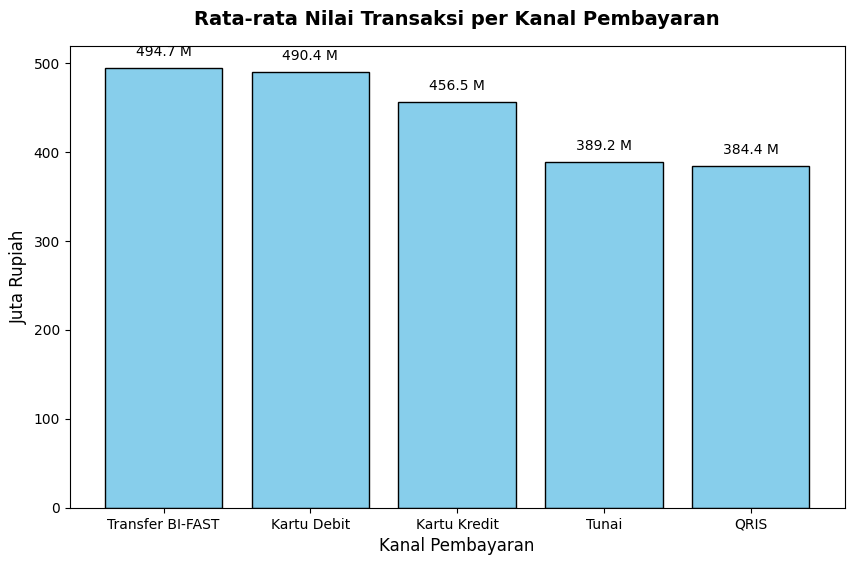

In [ ]:
import matplotlib.pyplot as plt

# 1. Hitung rata-rata Nilai_Transaksi untuk tiap Kanal_Pembayaran
rata_per_kanal = df_transaksi.groupby('Kanal_Pembayaran')['Nilai_Transaksi'].mean()

# 2. Urutkan dari rata-rata terbesar ke terkecil
rata_per_kanal = rata_per_kanal.sort_values(ascending=False)

# 3. Ubah nilai ke satuan Juta Rupiah supaya mudah dibaca
rata_per_kanal_juta = rata_per_kanal / 1000000

# 4. Buat diagram batang vertikal
plt.figure(figsize=(10, 6))
batang = plt.bar(rata_per_kanal_juta.index, rata_per_kanal_juta.values, color='skyblue', edgecolor='black')

# 5. Beri judul, label sumbu, dan tampilkan angka di atas tiap batang
plt.title('Rata-rata Nilai Transaksi per Kanal Pembayaran', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Juta Rupiah', fontsize=12)
plt.xlabel('Kanal Pembayaran', fontsize=12)

# Menambahkan label angka di atas setiap batang grafik
for b in batang:
    tinggi = b.get_height()
    plt.text(b.get_x() + b.get_width()/2.0, tinggi + 10, f'{tinggi:.1f} M', ha='center', va='bottom', fontsize=10)

# 6. Simpan gambar ke file PNG dengan dpi 150
plt.savefig('grafik_1_kanal.png', dpi=150, bbox_inches='tight')

# 7. Tampilkan grafik di layar
plt.show()

                             Usia  Frekuensi_Gunakan_QRIS  Kepuasan_Layanan_QRIS  Persepsi_Keamanan_Transaksi  Pengetahuan_BI_FAST  Niat_Menggunakan_Lagi  Loyalitas
Usia                         1.00                    0.07                   0.05                        -0.15                -0.11                   0.12       0.03
Frekuensi_Gunakan_QRIS       0.07                    1.00                  -0.09                         0.02                 0.04                  -0.07       0.02
Kepuasan_Layanan_QRIS        0.05                   -0.09                   1.00                         0.01                 0.09                   0.13      -0.09
Persepsi_Keamanan_Transaksi -0.15                    0.02                   0.01                         1.00                 0.03                   0.05       0.22
Pengetahuan_BI_FAST         -0.11                    0.04                   0.09                         0.03                 1.00                  -0.11      -0.08
Niat_Mengg

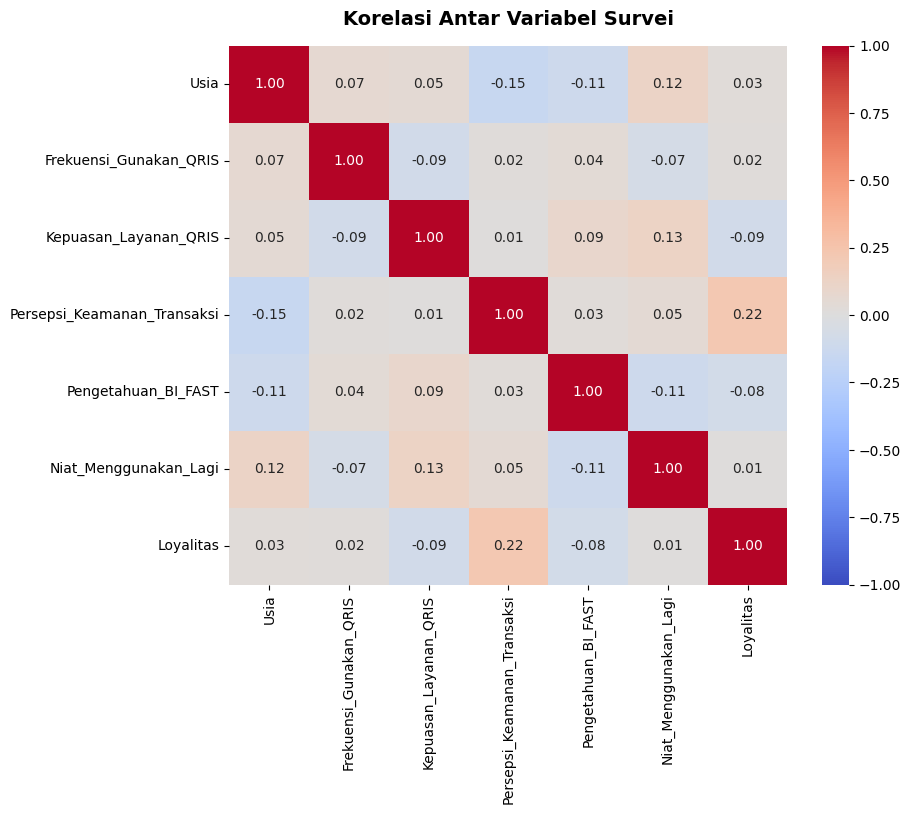

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Ambil hanya 7 kolom angka yang ditentukan
kolom_survei = df_survei[[
    'Usia',
    'Frekuensi_Gunakan_QRIS',
    'Kepuasan_Layanan_QRIS',
    'Persepsi_Keamanan_Transaksi',
    'Pengetahuan_BI_FAST',
    'Niat_Menggunakan_Lagi',
    'Loyalitas'
]]

# 2. Hitung matriks korelasi Pearson dan bulatkan 2 angka di belakang koma
korelasi_survei = kolom_survei.corr().round(2)

# 3. Tampilkan tabel korelasi secara utuh
print(korelasi_survei.to_string())

# 4. Buat visualisasi heatmap menggunakan seaborn
plt.figure(figsize=(9, 7))
sns.heatmap(
    korelasi_survei,
    annot=True,
    fmt=".2f",
    vmin=-1,
    vmax=1,
    cmap="coolwarm"
)

# 5. Beri judul pada grafik
plt.title("Korelasi Antar Variabel Survei", fontsize=14, fontweight="bold", pad=15)

# 6. Simpan gambar ke file PNG dengan dpi 150
plt.savefig("grafik_3_korelasi.png", dpi=150, bbox_inches="tight")

# 7. Tampilkan grafik di layar
plt.show()

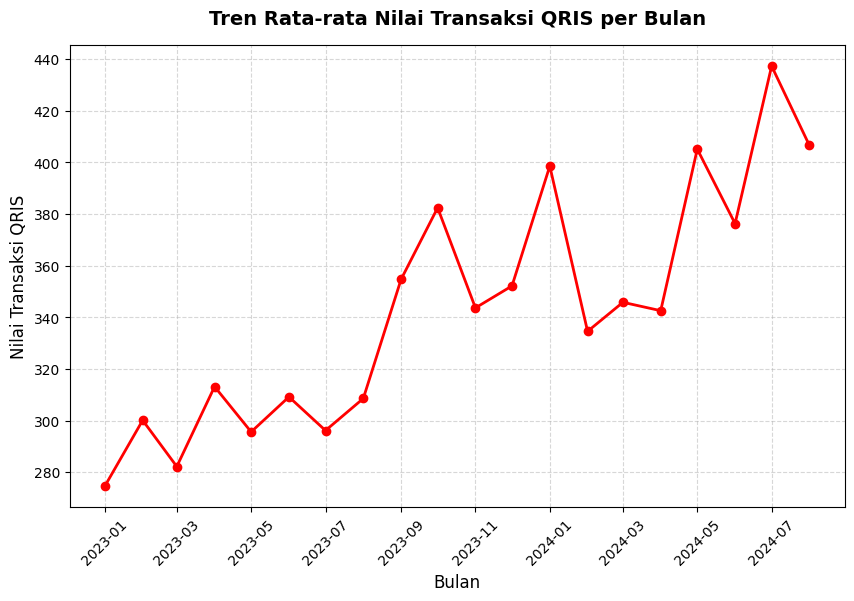

In [ ]:
# 1. Hitung rata-rata Nilai_Transaksi_QRIS untuk setiap Bulan (semua provinsi digabung)
rata_per_bulan = df_makro.groupby('Bulan')['Nilai_Transaksi_QRIS'].mean()

# 2. Pastikan urutan bulan runtut dari yang paling awal ke paling akhir
rata_per_bulan = rata_per_bulan.sort_index()

# 3. Atur ukuran kanvas grafik
plt.figure(figsize=(10, 6))

# 4. Buat diagram garis dengan titik penanda (marker 'o') di setiap bulan
plt.plot(
    rata_per_bulan.index,
    rata_per_bulan.values,
    marker='o',
    color='red',
    linewidth=2,
    label='Rata-rata Nilai Transaksi'
)

# 5. Beri judul grafik dan label informasi untuk setiap sumbu
plt.title("Tren Rata-rata Nilai Transaksi QRIS per Bulan", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Bulan", fontsize=12)
plt.ylabel("Nilai Transaksi QRIS", fontsize=12)

# 6. Putar teks tanggal di sumbu X agar rapi dan tambahkan garis bantu (grid)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)

# 7. Simpan gambar ke file PNG dengan kualitas tinggi (dpi 150)
plt.savefig("grafik_2_tren.png", dpi=150, bbox_inches="tight")

# 8. Tampilkan grafik di layar Google Colab
plt.show()

### Analisis Regresi Sederhana dari sheet makro

Koefisien Regresi (Slope) : 0.6355
Konstanta (Intercept)    : 5.5007
Koefisien Determinasi R² : 0.9404
Korelasi Pearson (r)      : 0.9698


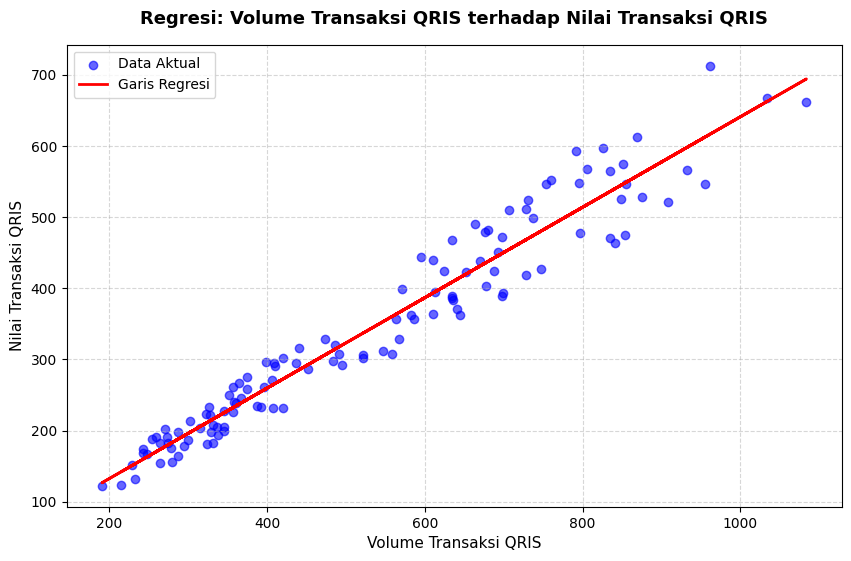

In [ ]:
from sklearn.linear_model import LinearRegression

# 1. Siapkan variabel independen (X) dan dependen (y)
# X harus berbentuk dua dimensi (menggunakan kurung siku ganda)
X = df_makro[['Volume_Transaksi_QRIS']]
y = df_makro['Nilai_Transaksi_QRIS']

# 2. Buat model regresi linear dan latih menggunakan seluruh data
model = LinearRegression()
model.fit(X, y)

# 3. Ambil parameter model hasil estimasi
koefisien_regresi = model.coef_[0]
intercept_regresi = model.intercept_
r_kuadrat = model.score(X, y)

# 4. Hitung korelasi Pearson antara kedua variabel tersebut
korelasi_volume_nilai = df_makro['Volume_Transaksi_QRIS'].corr(df_makro['Nilai_Transaksi_QRIS'])

# 5. Tampilkan metrik hasil analisis regresi ke layar
print(f"Koefisien Regresi (Slope) : {koefisien_regresi:.4f}")
print(f"Konstanta (Intercept)    : {intercept_regresi:.4f}")
print(f"Koefisien Determinasi R² : {r_kuadrat:.4f}")
print(f"Korelasi Pearson (r)      : {korelasi_volume_nilai:.4f}")

# 6. Hitung nilai prediksi untuk menggambar garis regresi
y_prediksi = model.predict(X)

# 7. Visualisasikan titik data asli dan garis regresi
plt.figure(figsize=(10, 6))

# Gambar scatter plot untuk data aktual
plt.scatter(df_makro['Volume_Transaksi_QRIS'], df_makro['Nilai_Transaksi_QRIS'], color='blue', alpha=0.6, label='Data Aktual')

# Gambar garis regresi linear hasil prediksi
plt.plot(df_makro['Volume_Transaksi_QRIS'], y_prediksi, color='red', linewidth=2, label='Garis Regresi')

# Beri judul, label sumbu, grid, dan legenda
plt.title("Regresi: Volume Transaksi QRIS terhadap Nilai Transaksi QRIS", fontsize=13, fontweight='bold', pad=15)
plt.xlabel("Volume Transaksi QRIS", fontsize=11)
plt.ylabel("Nilai Transaksi QRIS", fontsize=11)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

# 8. Simpan grafik ke dalam file PNG
plt.savefig("grafik_4_regresi.png", dpi=150, bbox_inches="tight")

# 9. Tampilkan grafik di layar
plt.show()

Kalau volumenya naik maka nilai transaksi naik sebesar 0.64 poin

R2 = hubungan berbanding lurus sebesar 94&



## **BUAT REPORT DI MS WORD**

5a. Kerangka + Tabel + Gambar Viusalisasi

In [ ]:
!pip install -q python-docx

import docx
from docx.shared import Inches, Pt
from google.colab import files

# 1. Inisialisasi dokumen baru
doc = docx.Document()

# Judul Utama Laporan
judul = doc.add_paragraph()
run_judul = judul.add_run("Laporan Analisis Data Latihan Bank Indonesia")
run_judul.font.size = Pt(18)
run_judul.bold = True
judul.alignment = docx.enum.text.WD_ALIGN_PARAGRAPH.CENTER

# Tambahkan paragraf kosong sebagai pemisah
doc.add_paragraph()

# =========================================================================
# BAGIAN A: STATISTIK DESKRIPTIF
# =========================================================================

doc.add_heading("A. Statistik Deskriptif", level=1)

# Fungsi bantu untuk memformat angka dengan gaya Indonesia
def format_indo(nilai, desimal):
    if pd.isna(nilai):
        return "-"
    try:
        # Format dasar dengan jumlah desimal yang ditentukan
        teks_format = f"{nilai:.{desimal}f}"
        if "." in teks_format:
            bagian_bulat, bagian_desimal = teks_format.split(".")
        else:
            bagian_bulat, bagian_desimal = teks_format, ""

        # Beri pemisah ribuan dengan titik untuk bagian bulat
        nilai_bulat = int(bagian_bulat)
        bagian_bulat_formatted = f"{nilai_bulat:,}".replace(",", ".")

        if desimal > 0:
            return f"{bagian_bulat_formatted},{bagian_desimal}"
        else:
            return bagian_bulat_formatted
    except:
        return str(nilai)

# --- A.1 Data Transaksi ---
doc.add_heading("A.1 Data Transaksi", level=2)

# Buat tabel transaksi di Word (8 baris data + 1 baris header, 3 kolom)
tabel_transaksi = doc.add_table(rows=1, cols=3)
tabel_transaksi.style = "Table Grid"

# Header tabel
hdr_cells = tabel_transaksi.rows[0].cells
hdr_cells[0].text = "Statistik"
hdr_cells[1].text = "Nilai_Transaksi"
hdr_cells[2].text = "Biaya_Admin"

# Atur huruf tebal untuk header dan ukuran font 8 pt
for cell in hdr_cells:
    for p in cell.paragraphs:
        for run in p.runs:
            run.bold = True
            run.font.size = Pt(8)

# Isi data statistik deskriptif untuk transaksi (0 desimal)
for indeks in ringkasan_transaksi.index:
    row_cells = tabel_transaksi.add_row().cells
    row_cells[0].text = str(indeks)
    row_cells[1].text = format_indo(ringkasan_transaksi.loc[indeks, "Nilai_Transaksi"], 0)
    row_cells[2].text = format_indo(ringkasan_transaksi.loc[indeks, "Biaya_Admin"], 0)

    # Atur ukuran font seluruh isi tabel menjadi 8 pt
    for cell in row_cells:
        for p in cell.paragraphs:
            for run in p.runs:
                run.font.size = Pt(8)

doc.add_paragraph() # Paragraf kosong setelah tabel

# --- A.2 Data Survei Persepsi ---
doc.add_heading("A.2 Data Survei Persepsi", level=2)

kolom_survei_all = list(ringkasan_survei.columns)
tabel_survei = doc.add_table(rows=1, cols=len(kolom_survei_all) + 1)
tabel_survei.style = "Table Grid"

# Header tabel
hdr_cells_survei = tabel_survei.rows[0].cells
hdr_cells_survei[0].text = "Statistik"
for i, col_name in enumerate(kolom_survei_all):
    hdr_cells_survei[i + 1].text = col_name

for cell in hdr_cells_survei:
    for p in cell.paragraphs:
        for run in p.runs:
            run.bold = True
            run.font.size = Pt(8)

# Isi data statistik deskriptif untuk survei (2 desimal)
for indeks in ringkasan_survei.index:
    row_cells = tabel_survei.add_row().cells
    row_cells[0].text = str(indeks)
    for i, col_name in enumerate(kolom_survei_all):
        row_cells[i + 1].text = format_indo(ringkasan_survei.loc[indeks, col_name], 2)

    for cell in row_cells:
        for p in cell.paragraphs:
            for run in p.runs:
                run.font.size = Pt(8)

doc.add_paragraph() # Paragraf kosong setelah tabel

# --- A.3 Data Makro Inklusi Keuangan ---
doc.add_heading("A.3 Data Makro Inklusi Keuangan", level=2)

kolom_makro_all = list(ringkasan_makro.columns)
tabel_makro = doc.add_table(rows=1, cols=len(kolom_makro_all) + 1)
tabel_makro.style = "Table Grid"

# Header tabel
hdr_cells_makro = tabel_makro.rows[0].cells
hdr_cells_makro[0].text = "Statistik"
for i, col_name in enumerate(kolom_makro_all):
    hdr_cells_makro[i + 1].text = col_name

for cell in hdr_cells_makro:
    for p in cell.paragraphs:
        for run in p.runs:
            run.bold = True
            run.font.size = Pt(8)

# Isi data statistik deskriptif untuk makro (2 desimal)
for indeks in ringkasan_makro.index:
    row_cells = tabel_makro.add_row().cells
    row_cells[0].text = str(indeks)
    for i, col_name in enumerate(kolom_makro_all):
        row_cells[i + 1].text = format_indo(ringkasan_makro.loc[indeks, col_name], 2)

    for cell in row_cells:
        for p in cell.paragraphs:
            for run in p.runs:
                run.font.size = Pt(8)

doc.add_paragraph() # Paragraf kosong setelah tabel

# =========================================================================
# BAGIAN B: VISUALISASI
# =========================================================================

doc.add_heading("B. Visualisasi", level=1)

# Grafik 1: Kanal Pembayaran
doc.add_picture("grafik_1_kanal.png", width=Inches(5.5))
p1 = doc.add_paragraph()
run_p1 = p1.add_run("Gambar 1. Rata-rata nilai transaksi per kanal pembayaran.")
run_p1.font.size = Pt(10)
doc.add_paragraph()

# Grafik 2: Tren
doc.add_picture("grafik_2_tren.png", width=Inches(5.5))
p2 = doc.add_paragraph()
run_p2 = p2.add_run("Gambar 2. Tren rata-rata nilai transaksi QRIS per bulan.")
run_p2.font.size = Pt(10)
doc.add_paragraph()

# Grafik 3: Korelasi
doc.add_picture("grafik_3_korelasi.png", width=Inches(5.5))
p3 = doc.add_paragraph()
run_p3 = p3.add_run("Gambar 3. Korelasi antar variabel survei.")
run_p3.font.size = Pt(10)
doc.add_paragraph()

# Grafik 4: Regresi
doc.add_picture("grafik_4_regresi.png", width=Inches(5.5))
p4 = doc.add_paragraph()
run_p4 = p4.add_run("Gambar 4. Regresi volume transaksi QRIS terhadap nilai transaksi QRIS.")
run_p4.font.size = Pt(10)

# Simpan dokumen ke dalam file
nama_laporan = "laporan_analisis_bi.docx"
doc.save(nama_laporan)
print(f"Laporan berhasil dibuat dan disimpan sebagai: {nama_laporan}")

# Unduh laporan otomatis ke lokal komputer pengguna
files.download(nama_laporan)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 4.7 MB/s eta 0:00:00


Exception ignored in: <function ZipFile.__del__ at 0x7ecc4fef2160>
Traceback (most recent call last):
  File "/usr/lib/python3.13/zipfile/__init__.py", line 2017, in __del__
    self.close()
  File "/usr/lib/python3.13/zipfile/__init__.py", line 2034, in close
    self.fp.seek(self.start_dir)
ValueError: seek of closed file


Laporan berhasil dibuat dan disimpan sebagai: laporan_analisis_bi.docx


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

5b. Tambah Penjelasan ke dalam Laporan

In [ ]:
import docx
from docx.shared import Inches, Pt
from google.colab import files
import pandas as pd

# 1. Inisialisasi dokumen baru
doc = docx.Document()

# Judul Utama Laporan
judul = doc.add_paragraph()
run_judul = judul.add_run("Laporan Analisis Data Latihan Bank Indonesia")
run_judul.font.size = Pt(18)
run_judul.bold = True
judul.alignment = docx.enum.text.WD_ALIGN_PARAGRAPH.CENTER

# Tambahkan paragraf kosong sebagai pemisah
doc.add_paragraph()

# =========================================================================
# BAGIAN BARU: PENDAHULUAN
# =========================================================================
doc.add_heading("Pendahuluan", level=1)
paragraf_pendahuluan = doc.add_paragraph()
paragraf_pendahuluan.add_run(
    "Laporan ini merangkum hasil analisis tiga kumpulan data latihan yang telah dibersihkan: "
    "data transaksi (194 baris, periode Januari sampai Desember 2024), data survei persepsi responden "
    "(146 baris), dan data makro inklusi keuangan di enam provinsi (120 baris, periode Januari 2023 "
    "sampai Agustus 2024). Analisis mencakup statistik deskriptif, visualisasi, korelasi, "
    "dan regresi linear sederhana."
)

doc.add_paragraph() # Paragraf kosong sebagai pemisah

# =========================================================================
# BAGIAN A: STATISTIK DESKRIPTIF
# =========================================================================
doc.add_heading("A. Statistik Deskriptif", level=1)

# Fungsi bantu untuk memformat angka dengan gaya Indonesia
def format_indo(nilai, desimal):
    if pd.isna(nilai):
        return "-"
    try:
        # Format dasar dengan jumlah desimal yang ditentukan
        teks_format = f"{nilai:.{desimal}f}"
        if "." in teks_format:
            bagian_bulat, bagian_desimal = teks_format.split(".")
        else:
            bagian_bulat, bagian_desimal = teks_format, ""

        # Beri pemisah ribuan dengan titik untuk bagian bulat
        nilai_bulat = int(bagian_bulat)
        bagian_bulat_formatted = f"{nilai_bulat:,}".replace(",", ".")

        if desimal > 0:
            return f"{bagian_bulat_formatted},{bagian_desimal}"
        else:
            return bagian_bulat_formatted
    except:
        return str(nilai)

# --- A.1 Data Transaksi ---
doc.add_heading("A.1 Data Transaksi", level=2)

# Buat tabel transaksi di Word (3 kolom)
tabel_transaksi = doc.add_table(rows=1, cols=3)
tabel_transaksi.style = "Table Grid"

# Header tabel
hdr_cells = tabel_transaksi.rows[0].cells
hdr_cells[0].text = "Statistik"
hdr_cells[1].text = "Nilai_Transaksi"
hdr_cells[2].text = "Biaya_Admin"

# Atur huruf tebal untuk header dan ukuran font 8 pt
for cell in hdr_cells:
    for p in cell.paragraphs:
        for run in p.runs:
            run.bold = True
            run.font.size = Pt(8)

# Isi data statistik deskriptif untuk transaksi (0 desimal)
for indeks in ringkasan_transaksi.index:
    row_cells = tabel_transaksi.add_row().cells
    row_cells[0].text = str(indeks)
    row_cells[1].text = format_indo(ringkasan_transaksi.loc[indeks, "Nilai_Transaksi"], 0)
    row_cells[2].text = format_indo(ringkasan_transaksi.loc[indeks, "Biaya_Admin"], 0)

    # Atur ukuran font seluruh isi tabel menjadi 8 pt
    for cell in row_cells:
        for p in cell.paragraphs:
            for run in p.runs:
                run.font.size = Pt(8)

doc.add_paragraph() # Paragraf kosong setelah tabel

# --- A.2 Data Survei Persepsi ---
doc.add_heading("A.2 Data Survei Persepsi", level=2)

kolom_survei_all = list(ringkasan_survei.columns)
tabel_survei = doc.add_table(rows=1, cols=len(kolom_survei_all) + 1)
tabel_survei.style = "Table Grid"

# Header tabel
hdr_cells_survei = tabel_survei.rows[0].cells
hdr_cells_survei[0].text = "Statistik"
for i, col_name in enumerate(kolom_survei_all):
    hdr_cells_survei[i + 1].text = col_name

for cell in hdr_cells_survei:
    for p in cell.paragraphs:
        for run in p.runs:
            run.bold = True
            run.font.size = Pt(8)

# Isi data statistik deskriptif untuk survei (2 desimal)
for indeks in ringkasan_survei.index:
    row_cells = tabel_survei.add_row().cells
    row_cells[0].text = str(indeks)
    for i, col_name in enumerate(kolom_survei_all):
        row_cells[i + 1].text = format_indo(ringkasan_survei.loc[indeks, col_name], 2)

    for cell in row_cells:
        for p in cell.paragraphs:
            for run in p.runs:
                run.font.size = Pt(8)

doc.add_paragraph() # Paragraf kosong setelah tabel

# --- A.3 Data Makro Inklusi Keuangan ---
doc.add_heading("A.3 Data Makro Inklusi Keuangan", level=2)

kolom_makro_all = list(ringkasan_makro.columns)
tabel_makro = doc.add_table(rows=1, cols=len(kolom_makro_all) + 1)
tabel_makro.style = "Table Grid"

# Header tabel
hdr_cells_makro = tabel_makro.rows[0].cells
hdr_cells_makro[0].text = "Statistik"
for i, col_name in enumerate(kolom_makro_all):
    hdr_cells_makro[i + 1].text = col_name

for cell in hdr_cells_makro:
    for p in cell.paragraphs:
        for run in p.runs:
            run.bold = True
            run.font.size = Pt(8)

# Isi data statistik deskriptif untuk makro (2 desimal)
for indeks in ringkasan_makro.index:
    row_cells = tabel_makro.add_row().cells
    row_cells[0].text = str(indeks)
    for i, col_name in enumerate(kolom_makro_all):
        row_cells[i + 1].text = format_indo(ringkasan_makro.loc[indeks, col_name], 2)

    for cell in row_cells:
        for p in cell.paragraphs:
            for run in p.runs:
                run.font.size = Pt(8)

doc.add_paragraph() # Paragraf kosong setelah tabel

# =========================================================================
# BAGIAN B: VISUALISASI
# =========================================================================
doc.add_heading("B. Visualisasi", level=1)

# Grafik 1: Kanal Pembayaran
doc.add_picture("grafik_1_kanal.png", width=Inches(5.5))
p1 = doc.add_paragraph()
run_p1 = p1.add_run("Gambar 1. Rata-rata nilai transaksi per kanal pembayaran.")
run_p1.font.size = Pt(10)
doc.add_paragraph()

# Grafik 2: Tren
doc.add_picture("grafik_2_tren.png", width=Inches(5.5))
p2 = doc.add_paragraph()
run_p2 = p2.add_run("Gambar 2. Tren rata-rata nilai transaksi QRIS per bulan.")
run_p2.font.size = Pt(10)
doc.add_paragraph()

# Grafik 3: Korelasi
doc.add_picture("grafik_3_korelasi.png", width=Inches(5.5))
p3 = doc.add_paragraph()
run_p3 = p3.add_run("Gambar 3. Korelasi antar variabel survei.")
run_p3.font.size = Pt(10)
doc.add_paragraph()

# Grafik 4: Regresi
doc.add_picture("grafik_4_regresi.png", width=Inches(5.5))
p4 = doc.add_paragraph()
run_p4 = p4.add_run("Gambar 4. Regresi volume transaksi QRIS terhadap nilai transaksi QRIS.")
run_p4.font.size = Pt(10)

doc.add_paragraph() # Paragraf kosong sebagai pemisah

# =========================================================================
# BAGIAN BARU: C. CATATAN DATA
# =========================================================================
doc.add_heading("C. Catatan Data", level=1)

paragraf_c1 = doc.add_paragraph()
paragraf_c1.add_run(
    "Berkas latihan semula berisi 200 baris data transaksi, 150 baris data survei, "
    "dan 120 baris data makro. Setelah pembersihan, jumlah baris menjadi 194, 146, dan 120."
)

paragraf_c2 = doc.add_paragraph()
paragraf_c2.add_run(
    "Aturan pembersihan yang digunakan: tanggal bergaris miring dibaca sebagai hari/bulan/tahun; "
    "usia dianggap wajar pada rentang 17 sampai 100 tahun; skala frekuensi penggunaan 1 sampai 7 "
    "dan skor survei lainnya 1 sampai 5; nilai negatif dan nilai ekstrem dikosongkan lalu diisi "
    "dengan median; sel teks yang kosong diisi dengan modus; data makro yang kosong diisi "
    "dengan median per provinsi."
)

paragraf_c3 = doc.add_paragraph()
paragraf_c3.add_run(
    "Keputusan pengisian median memengaruhi hasil. Pada kolom Nilai_Transaksi, nilai 419.292.000 "
    "muncul 10 kali karena berasal dari pengisian median, sehingga nilai tengah (50%) kolom tersebut "
    "sama dengan angka ini. Rata-rata dan sebaran kolom tersebut perlu dibaca dengan kehati-hatian."
)

doc.add_paragraph() # Paragraf kosong sebagai pemisah

# =========================================================================
# BAGIAN BARU: D. TEMUAN DAN KESIMPULAN
# =========================================================================
doc.add_heading("D. Temuan dan Kesimpulan", level=1)

# Simpan teks temuan dalam daftar (list) pasangan judul dan isi sesuai instruksi
temuan_list = [
    (
        "D.1 Kanal Pembayaran",
        "Rata-rata nilai transaksi tertinggi terdapat pada kanal Transfer BI-FAST (494,75 juta rupiah), "
        "disusul Kartu Debit (490,39 juta) dan Kartu Kredit (456,53 juta). Rata-rata terendah terdapat pada "
        "Tunai (389,20 juta) dan QRIS (384,35 juta). Perlu dicatat bahwa QRIS adalah kanal dengan jumlah "
        "transaksi terbanyak (67 dari 194 transaksi)."
    ),
    (
        "D.2 Tren Transaksi QRIS",
        "Rata-rata nilai transaksi QRIS per bulan cenderung naik, dari 274,62 pada Januari 2023 menjadi "
        "406,55 pada Agustus 2024, dengan puncak 437,30 pada Juli 2024. Kenaikan tersebut tidak mulus "
        "karena terdapat naik-turun antarbulan."
    ),
    (
        "D.3 Korelasi Variabel Survei",
        "Rata-rata skor survei berada di sekitar tengah skala, yaitu 2,85 sampai 3,16 pada skala 1 sampai 5 "
        "(frekuensi penggunaan QRIS rata-rata 3,96 pada skala 1 sampai 7). Seluruh korelasi antar variabel "
        "survei tergolong lemah. Korelasi tertinggi adalah Persepsi Keamanan Transaksi dengan Loyalitas (0,22) "
        "dan korelasi terendah adalah Usia dengan Persepsi Keamanan Transaksi (-0,15). Dengan demikian tidak "
        "ditemukan hubungan yang kuat antar variabel survei."
    ),
    (
        "D.4 Regresi Data Makro",
        "Pada data makro, regresi linear sederhana menunjukkan bahwa setiap kenaikan 1 poin Volume Transaksi QRIS "
        "diikuti kenaikan sekitar 0,64 poin Nilai Transaksi QRIS (koefisien 0,6355). Nilai R-kuadrat sebesar "
        "0,9404 dan korelasi sebesar 0,9698 menunjukkan hubungan yang sangat kuat. Pada volume besar (di atas "
        "sekitar 800), titik data lebih menyebar dari garis sehingga perkiraan pada rentang tersebut kurang "
        "presisi. Hubungan ini menunjukkan keterkaitan, bukan bukti sebab-akibat."
    ),
    (
        "D.5 Kesimpulan",
        "Secera ringkas: (1) nilai transaksi QRIS cenderung naik sepanjang periode pengamatan; "
        "(2) volume dan nilai transaksi QRIS berkaitan sangat kuat; (3) variabel survei tidak "
        "saling berhubungan secara kuat; (4) hasil pada data transaksi perlu dibaca dengan memperhatikan "
        "pengisian median."
    )
]

# Masukkan dengan for-loop biasa menggunakan heading level 2 untuk judul sub-bab
for sub_judul, isi_teks in temuan_list:
    doc.add_heading(sub_judul, level=2)
    p_temuan = doc.add_paragraph()
    p_temuan.add_run(isi_teks)

# Simpan dokumen ke file baru
nama_laporan_baru = "laporan_analisis_bi_lengkap.docx"
doc.save(nama_laporan_baru)
print(f"Laporan lengkap berhasil dibuat dan disimpan sebagai: {nama_laporan_baru}")

# Unduh laporan otomatis ke lokal komputer pengguna
files.download(nama_laporan_baru)


Laporan lengkap berhasil dibuat dan disimpan sebagai: laporan_analisis_bi_lengkap.docx


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>